In [1]:
# Healthy stomach baseline = real HPA nTPM (live API).
# H. pylori column = baseline * 2**log2FC, log2FC are LITERATURE ESTIMATES (HPA has no infection condition).
import csv, json, urllib.request

API = "https://www.proteinatlas.org/api/search_download.php?search={}&format=json&columns=g,eg,gd,t_RNA_stomach_1&compress=no"
LOG2FC = {  # H. pylori gastritis vs uninfected mucosa; edit with your own DE results
    "GKN1": -2.5, "TFF1": -1.5, "PGC": -1.0, "ATP4B": -1.2,
    "MUC5AC": -0.8, "ANGPTL4": 1.8, "CXCL8": 3.0, "LCN2": 2.2,
}

def hpa(gene):
    with urllib.request.urlopen(API.format(gene), timeout=30) as r:
        hit = next(g for g in json.load(r) if g["Gene"] == gene)
    return hit["Ensembl"], hit["Gene description"], float(hit["Tissue RNA - stomach 1 [nTPM]"])

rows = []
for gene, lfc in LOG2FC.items():
    ens, desc, healthy = hpa(gene)
    for cond, ntpm, fc, src in [
        ("Healthy", healthy, 0.0, "HPA stomach nTPM"),
        ("H_pylori", healthy * 2**lfc, lfc, "literature estimate"),
    ]:
        rows.append({"gene": gene, "ensembl": ens, "description": desc,
                     "condition": cond, "nTPM": round(ntpm, 1),
                     "log2FC_vs_healthy": fc, "source": src})

with open("hpa_gastric_hpylori.csv", "w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=rows[0])
    w.writeheader(); w.writerows(rows)

assert len(rows) == 16 and all(r["nTPM"] >= 0 for r in rows)
assert next(r for r in rows if r["gene"] == "CXCL8" and r["condition"] == "H_pylori")["nTPM"] > \
       next(r for r in rows if r["gene"] == "CXCL8" and r["condition"] == "Healthy")["nTPM"]
print(f"wrote hpa_gastric_hpylori.csv ({len(rows)} rows)")


wrote hpa_gastric_hpylori.csv (16 rows)


In [2]:
import pandas as pd
df = pd.read_csv("hpa_gastric_hpylori.csv")
df.pivot(index="gene", columns="condition", values="nTPM")


condition,H_pylori,Healthy
gene,,
ANGPTL4,73.1,21.0
ATP4B,436.1,1001.8
CXCL8,86.4,10.8
GKN1,6242.1,35310.8
LCN2,1576.0,343.0
MUC5AC,100.4,174.8
PGC,28791.9,57583.8
TFF1,2654.8,7508.8


In [4]:
df = pd.read_csv('hpa_gastric_hpylori.csv')
print(df.head())
print("Genes:", df['gene'].unique())
print("Conditions:", df['condition'].unique())
print(df.dtypes)

   gene          ensembl       description condition     nTPM  \
0  GKN1  ENSG00000169605      Gastrokine 1   Healthy  35310.8   
1  GKN1  ENSG00000169605      Gastrokine 1  H_pylori   6242.1   
2  TFF1  ENSG00000160182  Trefoil factor 1   Healthy   7508.8   
3  TFF1  ENSG00000160182  Trefoil factor 1  H_pylori   2654.8   
4   PGC  ENSG00000096088     Progastricsin   Healthy  57583.8   

   log2FC_vs_healthy               source  
0                0.0     HPA stomach nTPM  
1               -2.5  literature estimate  
2                0.0     HPA stomach nTPM  
3               -1.5  literature estimate  
4                0.0     HPA stomach nTPM  
Genes: ['GKN1' 'TFF1' 'PGC' 'ATP4B' 'MUC5AC' 'ANGPTL4' 'CXCL8' 'LCN2']
Conditions: ['Healthy' 'H_pylori']
gene                  object
ensembl               object
description           object
condition             object
nTPM                 float64
log2FC_vs_healthy    float64
source                object
dtype: object


In [5]:
pivot = df.pivot(index='gene', columns='condition', values='nTPM')
pivot

condition,H_pylori,Healthy
gene,,
ANGPTL4,73.1,21.0
ATP4B,436.1,1001.8
CXCL8,86.4,10.8
GKN1,6242.1,35310.8
LCN2,1576.0,343.0
MUC5AC,100.4,174.8
PGC,28791.9,57583.8
TFF1,2654.8,7508.8


In [6]:
pivot['change'] = pivot['H_pylori'] - pivot['Healthy']
pivot['pct_change'] = (pivot['change'] / pivot['Healthy']) * 100
pivot = pivot.sort_values('pct_change')
pivot

condition,H_pylori,Healthy,change,pct_change
gene,,,,
GKN1,6242.1,35310.8,-29068.7,-82.322406
TFF1,2654.8,7508.8,-4854.0,-64.644151
ATP4B,436.1,1001.8,-565.7,-56.468357
PGC,28791.9,57583.8,-28791.9,-50.000000
MUC5AC,100.4,174.8,-74.4,-42.562929
ANGPTL4,73.1,21.0,52.1,248.095238
LCN2,1576.0,343.0,1233.0,359.475219
CXCL8,86.4,10.8,75.6,700.000000


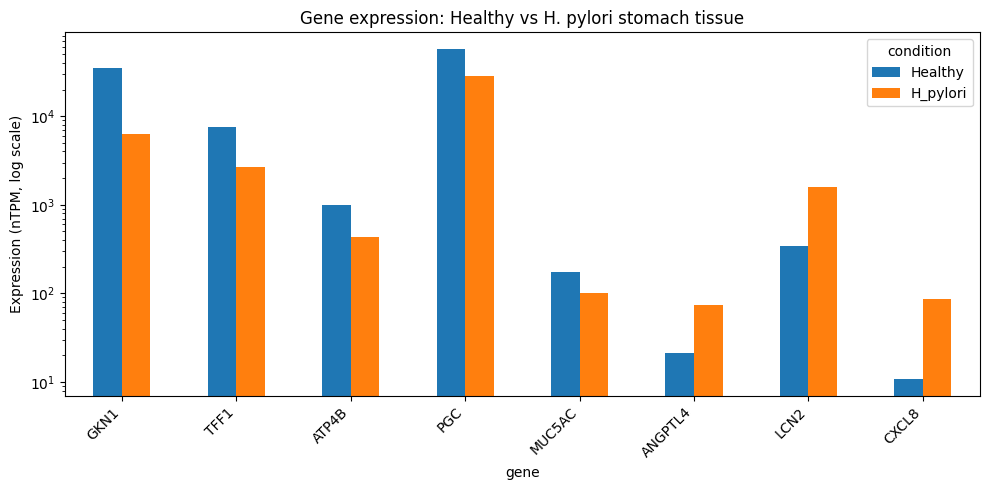

In [7]:
import matplotlib.pyplot as plt

pivot[['Healthy', 'H_pylori']].plot(kind='bar', figsize=(10, 5), logy=True)
plt.title('Gene expression: Healthy vs H. pylori stomach tissue')
plt.ylabel('Expression (nTPM, log scale)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
## Finding

The largest changes are inflammatory induction — CXCL8 (+700%) and LCN2 (+359%) — against
loss of the gastric mucosal protection program, led by GKN1 (−82%) and TFF1 (−65%), with
the parietal- and chief-cell markers ATP4B (−57%) and PGC (−50%) also depressed. The
direction is consistent: *H. pylori* colonization drives a neutrophil-recruiting chemokine
response while the surface mucous cells that normally restrain it are downregulated.

For diagnosis this matters because the two arms fail differently — CXCL8/LCN2 report active
inflammation that resolves after eradication, whereas GKN1/TFF1/ATP4B/PGC loss tracks
glandular atrophy, the change that carries the real gastric-cancer risk. Serum pepsinogen
(PGC) is already used clinically as an atrophy screen, so a panel pairing it with GKN1 could
separate "currently infected" from "permanently damaged."

> **Caveat:** Healthy values are real HPA stomach nTPM; the H. pylori values are the baseline
> scaled by literature-estimated log2FC, not measured in an infected cohort. Treat the
> directions as hypotheses to test against GEO data, not as results.